### Step 1: Import crucial libraries. ###

In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Step 2: Configuration ###

In [4]:
#-- Panda configutration --#
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
# -- Matplotlib and Seaborn plotting configuration -- #
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 10

### Step 3: Import crucial datasets ###

In [6]:
file_1 = '../Raw/Scats Data October 2006-1.csv'
file_2 = '../Raw/Scats Data October 2006-2.csv'
file_3 = '../Raw/Scats Data October 2006-3.csv'

### Step 4: Explore Scats data october 2006-1.csv ###

In [7]:
#-- Print the content in the file. --#
print(f"Content of {file_1}:") 
with open(file_1, 'r') as f:
    print(f.read())

Content of ../Raw/Scats Data October 2006-1.csv:
,,,,,,,,,,
,,,,,,,,,,
,,,,,,,,,,
,,,,,,,,,,
,Request: ,,,,,,,,,
,Attached is the 24 hour volume for 40 SCATS sites collected in Boroondara Council,,,,,,,,,
,Collection Period: 1st October 2006 to 31st October 2006 (1st October - last Sunday of School holidays),,,,,,,,,
,Data is available every 15minutes for each day collected. Data was validated as per ISD standards for all sites.,,,,,,,,,
,,,,,,,,,,
,,,,,,,,,,
,On selected days the Data for the following sites was very poor and was removed: ,,,,,,,,,
,970,,,,,,,,,
,2000,,,,,,,,,
,2820,,,,,,,,,
,3001,,,,,,,,,
,3002,,,,,,,,,
,3127,,,,,,,,,
,3682,,,,,,,,,
,3685,,,,,,,,,
,4057,,,,,,,,,
,4262,,,,,,,,,
,4263,,,,,,,,,
,4264,,,,,,, ,,
,4272,,,,,,,,, 
,4812,,,,,,,,,



### Step 5: Print poor days and saved in file .csv ###

In [8]:
output_path = os.path.join('../Processed/Bad_Records_List.csv')

bad_sites = []
try:
    with open(file_1, 'r') as f:
        lines = f.readlines()
        # Extracting IDs from the identified range
        for i in range(11, 25):
            # Remove commas and whitespace
            site_id = lines[i].replace(',', '').strip()
            if site_id:
                bad_sites.append(site_id)
                
    # -- Create a clean DataFrame -- #
    df_bad_records = pd.DataFrame({
        'Site_ID': bad_sites,
        'Issue': 'Very poor data / Removed on selected days',
        'Source_File': file_1
    })
    
    # -- Export to CSV for later use in Preprocessing -- #
    df_bad_records.to_csv(output_path, index=False)
    
    print("--- SUCCESS ---")
    print(f"Extracted {len(bad_sites)} bad sites from metadata.")
    print(f"File saved at: {output_path}")
    display(df_bad_records)

except Exception as e:
    print(f"Error during extraction: {e}")

--- SUCCESS ---
Extracted 14 bad sites from metadata.
File saved at: ../Processed/Bad_Records_List.csv


,Site_ID,Issue,Source_File
0,970,Very poor data / Removed on selected days,../Raw/Scats Data October 2006-1.csv
1,2000,Very poor data / Removed on selected days,../Raw/Scats Data October 2006-1.csv
2,2820,Very poor data / Removed on selected days,../Raw/Scats Data October 2006-1.csv
3,3001,Very poor data / Removed on selected days,../Raw/Scats Data October 2006-1.csv
4,3002,Very poor data / Removed on selected days,../Raw/Scats Data October 2006-1.csv
5,3127,Very poor data / Removed on selected days,../Raw/Scats Data October 2006-1.csv
6,3682,Very poor data / Removed on selected days,../Raw/Scats Data October 2006-1.csv
7,3685,Very poor data / Removed on selected days,../Raw/Scats Data October 2006-1.csv
8,4057,Very poor data / Removed on selected days,../Raw/Scats Data October 2006-1.csv
9,4262,Very poor data / Removed on selected days,../Raw/Scats Data October 2006-1.csv


### Step 6: Explore Second .csv file ###

In [9]:
#-- Print the content in the file. --#
print(f"Content of {file_2}:") 
with open(file_2, 'r') as f:
    print(f.read())

Content of ../Raw/Scats Data October 2006-2.csv:
									Start Time	0:00	0:15	0:30	0:45	1:00	1:15	1:30	1:45	2:00	2:15	2:30	2:45	3:00	3:15	3:30	3:45	4:00	4:15	4:30	4:45	5:00	5:15	5:30	5:45	6:00	6:15	6:30	6:45	7:00	7:15	7:30	7:45	8:00	8:15	8:30	8:45	9:00	9:15	9:30	9:45	10:00	10:15	10:30	10:45	11:00	11:15	11:30	11:45	12:00	12:15	12:30	12:45	13:00	13:15	13:30	13:45	14:00	14:15	14:30	14:45	15:00	15:15	15:30	15:45	16:00	16:15	16:30	16:45	17:00	17:15	17:30	17:45	18:00	18:15	18:30	18:45	19:00	19:15	19:30	19:45	20:00	20:15	20:30	20:45	21:00	21:15	21:30	21:45	22:00	22:15	22:30	22:45	23:00	23:15	23:30	23:45			
SCATS Number	Location	CD_MELWAY	NB_LATITUDE	NB_LONGITUDE	HF VicRoads Internal	VR Internal Stat	VR Internal Loc	NB_TYPE_SURVEY	Date	V00	V01	V02	V03	V04	V05	V06	V07	V08	V09	V10	V11	V12	V13	V14	V15	V16	V17	V18	V19	V20	V21	V22	V23	V24	V25	V26	V27	V28	V29	V30	V31	V32	V33	V34	V35	V36	V37	V38	V39	V40	V41	V42	V43	V44	V45	V46	V47	V48	V49	V50	V51	V52	V53	V54	V55	V56	V57	V58	V59	V60	V61	V62	V63	V64	V

In [12]:
#-- Load Data Traffic File 2. --#
df_traffic = pd.read_csv(file_2, sep='\t', skiprows=1)

# -- Data Cleaning: Remove potential empty columns -- #
# Sometimes the tab-separated file creates 'Unnamed' columns at the end
df_traffic = df_traffic.loc[:, ~df_traffic.columns.str.contains('^Unnamed')]

print("--- Data Loaded Successfully ---")
print(f"Variable 'df_traffic' is now ready with {df_traffic.shape[0]} records.")
display(df_traffic.head(3))


--- Data Loaded Successfully ---
Variable 'df_traffic' is now ready with 4192 records.


,SCATS Number,Location,CD_MELWAY,NB_LATITUDE,NB_LONGITUDE,HF VicRoads Internal,VR Internal Stat,VR Internal Loc,NB_TYPE_SURVEY,Date,V00,V01,V02,V03,V04,V05,V06,V07,V08,V09,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95
0,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,10/1/2006,86,83,52,58,59,44,31,37,30,24,16,24,25,25,15,6,21,17,15,15,16,21,27,21,25,32,61,48,56,66,77,79,67,93,103,130,154,149,210,229,250,246,266,254,300,275,322,292,315,314,308,280,357,298,281,289,345,297,233,227,273,225,265,257,233,244,259,264,265,253,243,210,216,202,177,169,167,136,131,128,118,121,87,113,142,112,114,97,97,66,81,50,59,47,29,34
1,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,10/2/2006,32,28,17,11,7,11,6,15,11,12,6,9,1,4,11,9,11,16,22,14,28,26,57,57,70,136,221,196,239,366,355,400,401,400,395,367,315,308,302,306,245,286,279,275,227,234,236,239,320,254,242,261,251,290,254,256,283,226,276,271,281,285,306,301,327,340,294,326,277,382,320,377,259,298,218,190,186,172,161,158,134,141,119,142,103,108,111,102,107,114,80,60,62,48,44,26
2,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,10/3/2006,26,32,21,14,10,12,13,10,9,7,8,5,5,6,11,12,8,11,13,10,23,37,64,95,90,183,219,251,302,307,410,351,411,408,405,372,330,366,360,317,312,289,293,299,293,273,264,264,290,260,286,272,274,270,259,313,281,347,280,266,347,277,328,318,357,347,381,288,358,338,365,369,296,335,269,232,211,198,176,163,155,140,135,129,139,146,130,132,114,86,93,90,73,57,29,40


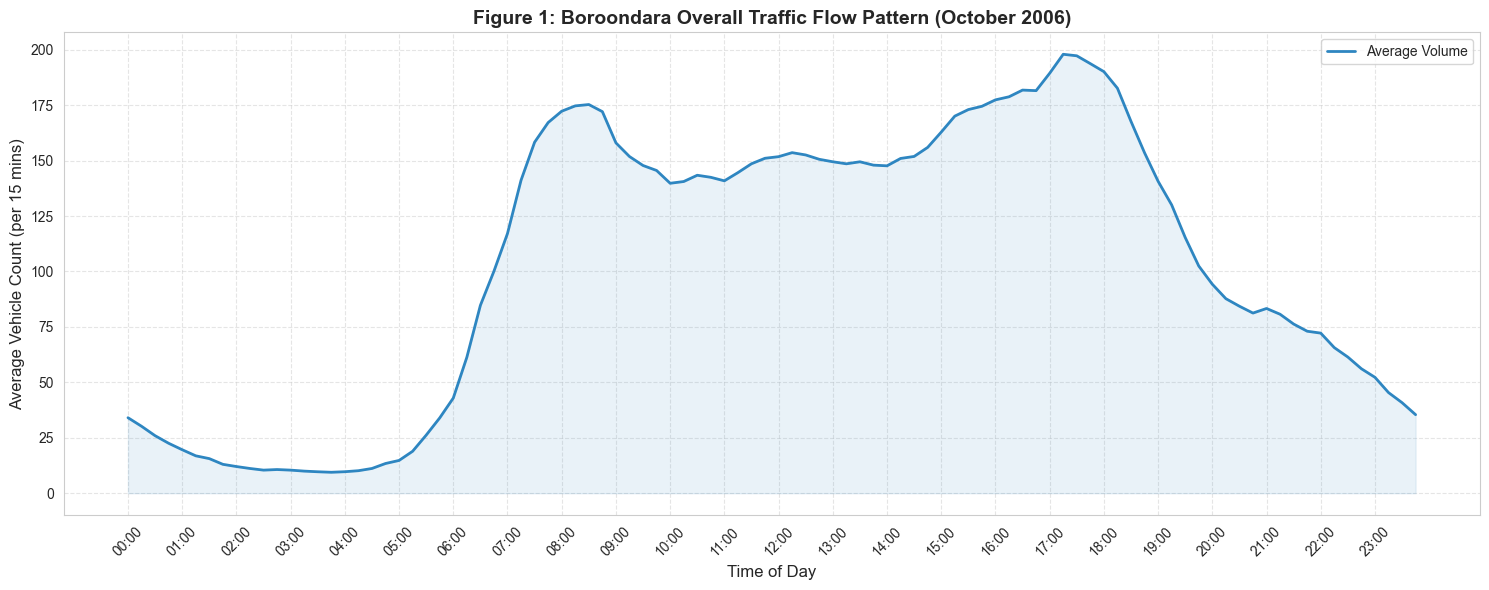

In [13]:
#--- overall Traffic Trend. --#
v_cols = [f'V{i:02d}' for i in range(96)]
time_labels = [f"{h:02d}:{m:02d}" for h in range(24) for m in [0, 15, 30, 45]]

#-- Calculate the average traffic profile across all sites. --#
avg_profile = df_traffic[v_cols].mean()

#-- Plotting Figure 1. --#
plt.figure(figsize=(15, 6))
plt.plot(time_labels, avg_profile.values, color='#2E86C1', linewidth=2, label='Average Volume')
plt.fill_between(time_labels, avg_profile.values, color='#2E86C1', alpha=0.1)

#-- Formatting. --#
plt.xticks(time_labels[::4], rotation=45) 
plt.title('Figure 1: Boroondara Overall Traffic Flow Pattern (October 2006)', fontsize=14, fontweight='bold')
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Average Vehicle Count (per 15 mins)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

#-- Save to Figures folder. --#
plt.tight_layout()
plt.savefig('../Figures/01_Overall_Traffic_Trend.png', dpi=300)
plt.show()

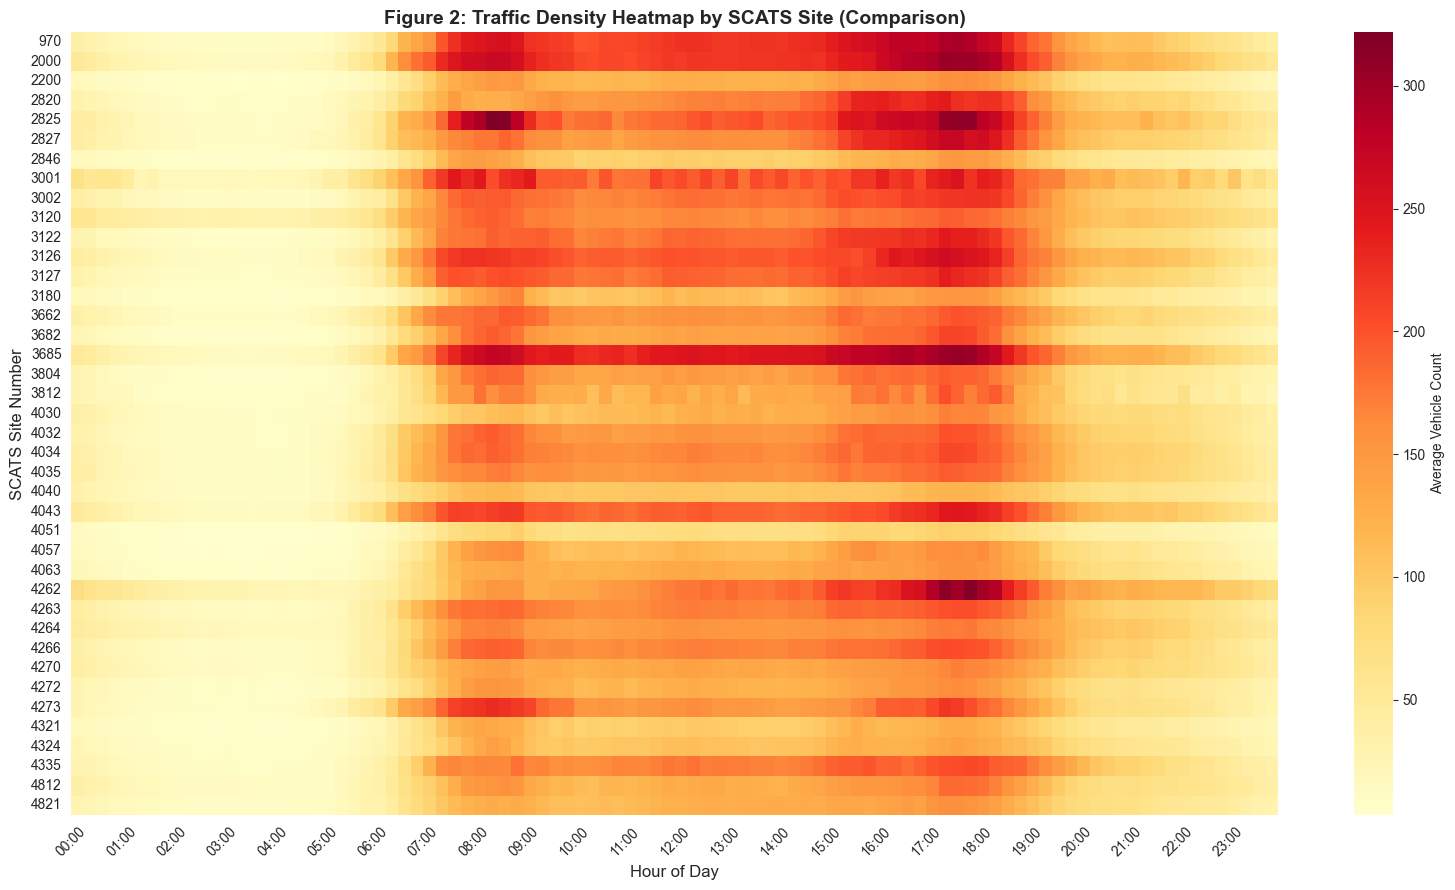

In [14]:
#-- Figure 2; Traffic Density heatmap. --#
#-- Grouping by SCATS Number to get mean volume per site. --#
heatmap_df = df_traffic.groupby('SCATS Number')[v_cols].mean()

#-- Plotting Figure 2. --#
plt.figure(figsize=(16, 9))
sns.heatmap(heatmap_df, cmap='YlOrRd', cbar_kws={'label': 'Average Vehicle Count'})

#-- Formatting X-axis to show hours instead of V00-V95 --#
plt.xticks(range(0, 96, 4), [f"{h:02d}:00" for h in range(24)], rotation=45)
plt.title('Figure 2: Traffic Density Heatmap by SCATS Site (Comparison)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('SCATS Site Number', fontsize=12)

#-- Save to Figures folder. --#
plt.tight_layout()
plt.savefig('../Figures/02_Traffic_Density_Heatmap.png', dpi=300)
plt.show()

### Step 7: Export two files .csv including busy and stable roads. ###

In [16]:
#-- This helps us rank which records (Site + Date) are generally 'Busy' or 'Quiet'. --#
v_cols = [f'V{i:02d}' for i in range(96)]
df_traffic['Daily_Total'] = df_traffic[v_cols].sum(axis=1)

#-- We take the top 25% busiest records and bottom 25% quietest records. --#
upper_threshold = df_traffic['Daily_Total'].quantile(0.75)
lower_threshold = df_traffic['Daily_Total'].quantile(0.25)

#-- Keeping all original columns. --#
df_busy_full = df_traffic[df_traffic['Daily_Total'] >= upper_threshold].copy()
df_quiet_full = df_traffic[df_traffic['Daily_Total'] <= lower_threshold].copy()

# -- Step 10: Save to Processed folder -- #
processed_path = '../Processed'
if not os.path.exists(processed_path):
    os.makedirs(processed_path)

df_busy_full.to_csv(f'{processed_path}/Full_Traffic_Busy.csv', index=False)
df_quiet_full.to_csv(f'{processed_path}/Full_Traffic_Quiet.csv', index=False)

print("--- FULL DATA EXPORT COMPLETED ---")
print(f"Busy Table: {df_busy_full.shape[0]} records saved to '{processed_path}/Full_Traffic_Busy.csv'")
print(f"Quiet Table: {df_quiet_full.shape[0]} records saved to '{processed_path}/Full_Traffic_Quiet.csv'")

# Quick check to see if all columns are preserved
print(f"\nNumber of columns preserved: {df_busy_full.shape[1]}")
display(df_busy_full.head(3))

--- FULL DATA EXPORT COMPLETED ---
Busy Table: 1049 records saved to '../Processed/Full_Traffic_Busy.csv'
Quiet Table: 1049 records saved to '../Processed/Full_Traffic_Quiet.csv'

Number of columns preserved: 107


C:\Users\DELL\AppData\Local\Temp\ipykernel_15720\2017784344.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_traffic['Daily_Total'] = df_traffic[v_cols].sum(axis=1)


,SCATS Number,Location,CD_MELWAY,NB_LATITUDE,NB_LONGITUDE,HF VicRoads Internal,VR Internal Stat,VR Internal Loc,NB_TYPE_SURVEY,Date,V00,V01,V02,V03,V04,V05,V06,V07,V08,V09,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,Daily_Total
0,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,10/1/2006,86,83,52,58,59,44,31,37,30,24,16,24,25,25,15,6,21,17,15,15,16,21,27,21,25,32,61,48,56,66,77,79,67,93,103,130,154,149,210,229,250,246,266,254,300,275,322,292,315,314,308,280,357,298,281,289,345,297,233,227,273,225,265,257,233,244,259,264,265,253,243,210,216,202,177,169,167,136,131,128,118,121,87,113,142,112,114,97,97,66,81,50,59,47,29,34,13780
1,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,10/2/2006,32,28,17,11,7,11,6,15,11,12,6,9,1,4,11,9,11,16,22,14,28,26,57,57,70,136,221,196,239,366,355,400,401,400,395,367,315,308,302,306,245,286,279,275,227,234,236,239,320,254,242,261,251,290,254,256,283,226,276,271,281,285,306,301,327,340,294,326,277,382,320,377,259,298,218,190,186,172,161,158,134,141,119,142,103,108,111,102,107,114,80,60,62,48,44,26,17362
2,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,10/3/2006,26,32,21,14,10,12,13,10,9,7,8,5,5,6,11,12,8,11,13,10,23,37,64,95,90,183,219,251,302,307,410,351,411,408,405,372,330,366,360,317,312,289,293,299,293,273,264,264,290,260,286,272,274,270,259,313,281,347,280,266,347,277,328,318,357,347,381,288,358,338,365,369,296,335,269,232,211,198,176,163,155,140,135,129,139,146,130,132,114,86,93,90,73,57,29,40,18870


### Step 8: Eplore Third Filees. ###

In [22]:
#-- Print the content in the file. --#
print(f"Content of {file_3}:") 
with open(file_3, 'r') as f:
    print(f.read())

Content of ../Raw/Scats Data October 2006-3.csv:
					
		Total day of data validated			
Count of Date					
SCATS Number	Location	Total			
0970	HIGH STREET_RD E of WARRIGAL_RD	31			
	HIGH STREET_RD W of WARRIGAL_RD	30			
	WARRIGAL_RD N of HIGH STREET_RD	31			
	WARRIGAL_RD S of HIGH STREET_RD	31			
2000	BURWOOD_HWY E of WARRIGAL_RD	29			
	TOORAK_RD W of WARRIGAL_RD	29			
	WARRIGAL_RD N of TOORAK_RD	28			
	WARRIGAL_RD S of BURWOOD_HWY	28			
2200	MAROONDAH_HWY E of UNION_RD	31			
	MAROONDAH_HWY W of UNION_RD	31			
	UNION_RD N of MAROONDAH_HWY	31			
	UNION_RD S of MAROONDAH_HWY	31			
2820	EARL_ST SE of PRINCESS_ST	31			
	PRINCESS_ST S of CHANDLER_HWY	30			
2825	BURKE_RD S of EASTERN_FWY	31			
2827	BULLEEN_RD N of THOMPSONS_RD	31			
	BULLEEN_RD S of EASTERN_FWY_W_BD_RAMPS	31			
	OFFRAMP_EASTERN_FWY E of BULLEEN_RD	31			
	OFFRAMP_EASTERN_FWY W of BULLEEN_RD	31			
2846	HIGH_ST E OF S.E.ARTERIAL	31			
	HIGH_ST W OF WILLS_ST	31			
	S.E.ARTERIAL N OF HIGH_ST	31			
	WILLS_ST NW OF HIGH_ST	31			
30

In [23]:
#-- Display Data Validity. --#
# -- Step 10: Load and display the validity report -- #
# We skip the first 3 rows as they are just titles and don't match the table structure
df_validity = pd.read_csv(file_3, sep='\t', skiprows=3)

# -- Data Cleaning for Display -- #
#-- Remove empty columns that often appear in SCATS tab-separated files. --#
df_validity = df_validity.loc[:, ~df_validity.columns.str.contains('^Unnamed')]

# 2. Fill missing SCATS Numbers (Forward Fill)
#-- In the original file, the ID is only written once for multiple locations. --#
df_validity['SCATS Number'] = df_validity['SCATS Number'].ffill()

# -- Show the data -- #
print("--- FILE 3: DATA VALIDITY REPORT (OCTOBER 2006) ---")
print(f"Total sensor records found: {len(df_validity)}")

# Display the first 20 rows to see the structure
display(df_validity.head(20))

# Summary of the 'Total' column (Days of valid data)
print("\nSummary Statistics for 'Total' days:")
display(df_validity['Total'].describe())

--- FILE 3: DATA VALIDITY REPORT (OCTOBER 2006) ---
Total sensor records found: 139


,SCATS Number,Location,Total
0,970.0,HIGH STREET_RD E of WARRIGAL_RD,31
1,970.0,HIGH STREET_RD W of WARRIGAL_RD,30
2,970.0,WARRIGAL_RD N of HIGH STREET_RD,31
3,970.0,WARRIGAL_RD S of HIGH STREET_RD,31
4,2000.0,BURWOOD_HWY E of WARRIGAL_RD,29
5,2000.0,TOORAK_RD W of WARRIGAL_RD,29
6,2000.0,WARRIGAL_RD N of TOORAK_RD,28
7,2000.0,WARRIGAL_RD S of BURWOOD_HWY,28
8,2200.0,MAROONDAH_HWY E of UNION_RD,31
9,2200.0,MAROONDAH_HWY W of UNION_RD,31



Summary Statistics for 'Total' days:


count    139.000000
mean      30.158273
std        4.074059
min        2.000000
25%       31.000000
50%       31.000000
75%       31.000000
max       62.000000
Name: Total, dtype: float64

### Step 9: Comine all files into one. ###

In [ ]:
# -- Step 11.1: Prepare File 3 (Validity) -- #
# We only need SCATS Number and the Total days
df_valid_mini = df_validity[['SCATS Number', 'Total']].copy()
df_valid_mini.columns = ['SCATS Number', 'Valid_Days']

# Remove duplicates in File 3 to avoid creating extra rows in File 2
df_valid_mini = df_valid_mini.drop_duplicates(subset=['SCATS Number'])

# -- Step 11.2: Merge File 3 INTO File 2 -- #
# Left join ensures we keep EVERY COLUMN and EVERY ROW from File 2
master_df = pd.merge(df_traffic, df_valid_mini, on='SCATS Number', how='left')

# -- Step 11.3: Quick Clean Up -- #
# If a site in File 2 isn't in File 3, we'll mark it as 0 valid days instead of NaN
master_df['Valid_Days'] = master_df['Valid_Days'].fillna(0).astype(int)

# -- Step 11.4: Export the full wide table -- #
output_path = '../Processed/Full_Traffic_With_Validity.csv'
master_df.to_csv(output_path, index=False)

print("--- MERGE SUCCESSFUL ---")
print(f"Total Columns: {len(master_df.columns)}")
print(f"New column added: 'Valid_Days'")
print(f"File saved at: {output_path}")

# Show the first 5 rows and verify V00-V95 are still there
display(master_df.head())

C:\Users\DELL\AppData\Local\Temp\ipykernel_15720\1420695690.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master_df['Date_Clean'] = pd.to_datetime(master_df['Date'], dayfirst=True, errors='coerce')


--- INTEGRATION COMPLETED ---
Total records for training: 159840


,SCATS Number,Location,Timestamp,Volume,Valid_Days
0,970,WARRIGAL_RD N of HIGH STREET_RD,2006-01-10 00:00:00,86,31
1,970,HIGH STREET_RD E of WARRIGAL_RD,2006-01-10 00:00:00,37,31
2,970,WARRIGAL_RD S of HIGH STREET_RD,2006-01-10 00:00:00,92,31
3,970,HIGH STREET_RD W of WARRIGAL_RD,2006-01-10 00:00:00,47,31
4,970,WARRIGAL_RD N of HIGH STREET_RD,2006-01-10 00:15:00,83,31
5,970,HIGH STREET_RD E of WARRIGAL_RD,2006-01-10 00:15:00,30,31
6,970,WARRIGAL_RD S of HIGH STREET_RD,2006-01-10 00:15:00,93,31
7,970,HIGH STREET_RD W of WARRIGAL_RD,2006-01-10 00:15:00,42,31
8,970,WARRIGAL_RD N of HIGH STREET_RD,2006-01-10 00:30:00,52,31
9,970,HIGH STREET_RD E of WARRIGAL_RD,2006-01-10 00:30:00,26,31
